# Projeto 1 — Variante de Regressão: Prevendo a Massa Corporal (Palmer Penguins)

O enunciado exige, além da classificação (`projeto1.ipynb`), uma variante de
regressão com `MSELoss` avaliada por MAE, RMSE e R². Este notebook é
independente e roda do início ao fim sozinho — não depende de nenhuma
variável do notebook de classificação, só do mesmo CSV.

**Alvo escolhido: `Body Mass (g)`.** É uma medida física contínua, não uma
categoria — exatamente o tipo de variável que a classificação não usa como
saída. Para não vazar o alvo entre as tarefas, ele sai da lista de
preditores, e `Species` entra no lugar: massa corporal varia muito entre as
três espécies (Gentoo é visivelmente mais pesado que Adelie/Chinstrap), então
a espécie é um preditor forte e com sentido biológico direto — o oposto de um
alvo trivial de acertar.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")


Dispositivo em uso: cpu


## 1. Dataset — mesma limpeza da classificação

In [2]:
df_raw = pd.read_csv('../data/penguins_lter.csv')

print(f"📊 Dimensão original do dataset: {df_raw.shape} (linhas, colunas)")

df_raw['Sex'] = df_raw['Sex'].replace('.', np.nan)
df = df_raw.dropna(subset=[
    'Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)',
    'Body Mass (g)', 'Sex'
]).copy()

print(f"🧹 Dimensão após remover ausentes: {df.shape}")


📊 Dimensão original do dataset: (344, 17) (linhas, colunas)
🧹 Dimensão após remover ausentes: (333, 17)


## 2. Atributos preditivos e alvo

Tudo que era preditor na classificação continua sendo, **menos** a própria
massa (agora é o alvo) e **mais** a espécie (agora é preditor, não mais o
alvo).

In [3]:
X_reg_raw = df.drop(columns=[
    'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)', 'studyName', 'Sample Number',
    'Individual ID', 'Date Egg', 'Comments', 'Stage', 'Region',
    'Clutch Completion', 'Body Mass (g)'
])
y_reg_raw = df['Body Mass (g)'].values.astype(np.float32)

print(f"📊 Dimensão de X_reg_raw: {X_reg_raw.shape}")
print(f"🎯 Alvo: Body Mass (g) — mín {y_reg_raw.min():.0f}g, máx {y_reg_raw.max():.0f}g, média {y_reg_raw.mean():.0f}g")


📊 Dimensão de X_reg_raw: (333, 6)
🎯 Alvo: Body Mass (g) — mín 2700g, máx 6300g, média 4207g


## 3. Split 70/15/15 — mesma proporção e seed da classificação

In [4]:
X_train_reg_df, X_temp_reg_df, y_train_reg, y_temp_reg = train_test_split(
    X_reg_raw, y_reg_raw, test_size=0.30, random_state=42
)
X_val_reg_df, X_test_reg_df, y_val_reg, y_test_reg = train_test_split(
    X_temp_reg_df, y_temp_reg, test_size=0.50, random_state=42
)

print(f"📊 Divisão dos dados de regressão realizada com sucesso:")
print(f"   • Conjunto de Treino:    {X_train_reg_df.shape[0]} amostras ({X_train_reg_df.shape[0]/len(X_reg_raw)*100:.1f}%)")
print(f"   • Conjunto de Validação: {X_val_reg_df.shape[0]} amostras ({X_val_reg_df.shape[0]/len(X_reg_raw)*100:.1f}%)")
print(f"   • Conjunto de Teste:     {X_test_reg_df.shape[0]} amostras ({X_test_reg_df.shape[0]/len(X_reg_raw)*100:.1f}%)")


📊 Divisão dos dados de regressão realizada com sucesso:
   • Conjunto de Treino:    233 amostras (70.0%)
   • Conjunto de Validação: 50 amostras (15.0%)
   • Conjunto de Teste:     50 amostras (15.0%)


## 4. Pré-processamento

`StandardScaler` nas colunas numéricas, `OneHotEncoder(drop='first')` nas
categóricas — agora incluindo `Species`. O alvo também é padronizado: mantém
a loss em ordem de grandeza O(1) em vez de O(1e6) em g², sem mudar o que o R²
mede — ele é invariante a transformação afim do alvo. MAE/RMSE finais são
reportados de volta em gramas via `inverse_transform`.


In [5]:
num_cols_reg = ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)']
cat_cols_reg = ['Island', 'Sex', 'Species']

preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_reg),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols_reg)
    ]
)

X_train_reg = preprocessor_reg.fit_transform(X_train_reg_df)
X_val_reg = preprocessor_reg.transform(X_val_reg_df)
X_test_reg = preprocessor_reg.transform(X_test_reg_df)
feature_names_reg = preprocessor_reg.get_feature_names_out()

print(f"Formato da Matriz Pré-processada (X_train_reg): {X_train_reg.shape}")
print(f"Nomes das {len(feature_names_reg)} colunas resultantes:")
for i, col in enumerate(feature_names_reg):
    print(f"   [{i:02d}] {col}")

target_scaler_reg = StandardScaler()
y_train_reg_scaled = target_scaler_reg.fit_transform(y_train_reg.reshape(-1, 1)).astype(np.float32).ravel()
y_val_reg_scaled = target_scaler_reg.transform(y_val_reg.reshape(-1, 1)).astype(np.float32).ravel()
y_test_reg_scaled = target_scaler_reg.transform(y_test_reg.reshape(-1, 1)).astype(np.float32).ravel()

print(f"\n🎯 Alvo padronizado -- média treino: {y_train_reg_scaled.mean():.4f}, desvio: {y_train_reg_scaled.std():.4f}")


Formato da Matriz Pré-processada (X_train_reg): (233, 8)
Nomes das 8 colunas resultantes:
   [00] num__Culmen Length (mm)
   [01] num__Culmen Depth (mm)
   [02] num__Flipper Length (mm)
   [03] cat__Island_Dream
   [04] cat__Island_Torgersen
   [05] cat__Sex_MALE
   [06] cat__Species_Chinstrap penguin (Pygoscelis antarctica)
   [07] cat__Species_Gentoo penguin (Pygoscelis papua)

🎯 Alvo padronizado -- média treino: -0.0000, desvio: 1.0000


## 5. Dataset e DataLoaders

In [6]:
class PinguinsRegressionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


batch_size = 32
train_dataset_reg = PinguinsRegressionDataset(X_train_reg, y_train_reg_scaled)
val_dataset_reg = PinguinsRegressionDataset(X_val_reg, y_val_reg_scaled)
test_dataset_reg = PinguinsRegressionDataset(X_test_reg, y_test_reg_scaled)

train_loader_reg = DataLoader(train_dataset_reg, batch_size=batch_size, shuffle=True)
val_loader_reg = DataLoader(val_dataset_reg, batch_size=batch_size, shuffle=False)
test_loader_reg = DataLoader(test_dataset_reg, batch_size=batch_size, shuffle=False)

print(f"🚚 DataLoaders de regressão criados com batch_size = {batch_size}:")
print(f"   • Lotes de Treino:    {len(train_loader_reg)} batches")
print(f"   • Lotes de Validação: {len(val_loader_reg)} batches")
print(f"   • Lotes de Teste:     {len(test_loader_reg)} batches")


🚚 DataLoaders de regressão criados com batch_size = 32:
   • Lotes de Treino:    8 batches
   • Lotes de Validação: 2 batches
   • Lotes de Teste:     2 batches


## 6. Arquitetura e treino

A mesma classe `PinguinMLP` da classificação (última camada sem ativação —
serve tanto para `CrossEntropyLoss` quanto para `MSELoss`), com
`output_dim=1`. Normalização `LayerNorm`, a mesma que venceu por `val_loss`
na comparação da classificação — não há razão para esperar que o veredito
mude aqui, já que o dataset e o regime de poucos exemplos são os mesmos.

O loop de treino é uma variação do `train_stable` da classificação: mesma
estrutura (zero_grad → forward → loss → backward → grad_norm → step,
validação por época, checkpoint pelo melhor `val_loss`), trocando a métrica
de acompanhamento por MAE, já que "acurácia" via `argmax` não existe em
regressão.

In [7]:
class PinguinMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[16], output_dim=1,
                 norm_type=None, activation='relu', dropout_rate=0.0):
        super().__init__()
        layers = []
        in_dim = input_dim

        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))

            if norm_type == 'batchnorm':
                layers.append(nn.BatchNorm1d(h_dim))
            elif norm_type == 'layernorm':
                layers.append(nn.LayerNorm(h_dim))

            if activation == 'relu':
                layers.append(nn.ReLU())
            elif activation == 'tanh':
                layers.append(nn.Tanh())
            elif activation == 'leaky_relu':
                layers.append(nn.LeakyReLU())

            if dropout_rate > 0.0:
                layers.append(nn.Dropout(dropout_rate))

            in_dim = h_dim

        layers.append(nn.Linear(in_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def initialize_weights(model, init_type='default'):
    if init_type == 'default':
        return
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if init_type == 'xavier_uniform':
                nn.init.xavier_uniform_(m.weight)
            elif init_type == 'kaiming_normal':
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)


In [8]:
from torch.utils.tensorboard import SummaryWriter
import datetime

%load_ext tensorboard


def train_stable_regression(
    model, train_loader, val_loader, criterion, optimizer,
    epochs=40, save_path="runs/projeto1/checkpoints/model_regression_body_mass.pt",
    clip_grad_norm=None, run_name="regressao_body_mass"
):
    model.to(device)
    history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': [], 'grad_norms': []}
    best_val_loss = float('inf')

    log_dir = os.path.join("runs", "projeto1", f"{run_name}_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
    writer = SummaryWriter(log_dir)

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, running_ae, total = 0.0, 0.0, 0
        epoch_grad_norms = []

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch).squeeze(1)
            loss = criterion(outputs, y_batch)
            loss.backward()

            grad_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    grad_norm += p.grad.detach().data.norm(2).item() ** 2
            grad_norm = grad_norm ** 0.5
            epoch_grad_norms.append(grad_norm)

            if clip_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad_norm)

            optimizer.step()

            running_loss += loss.item() * len(y_batch)
            running_ae += (outputs - y_batch).abs().sum().item()
            total += len(y_batch)

        epoch_train_loss = running_loss / total
        epoch_train_mae = running_ae / total
        avg_grad_norm = np.mean(epoch_grad_norms)

        model.eval()
        val_running_loss, val_running_ae, val_total = 0.0, 0.0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch).squeeze(1)
                loss = criterion(outputs, y_batch)
                val_running_loss += loss.item() * len(y_batch)
                val_running_ae += (outputs - y_batch).abs().sum().item()
                val_total += len(y_batch)

        epoch_val_loss = val_running_loss / val_total
        epoch_val_mae = val_running_ae / val_total

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_mae'].append(epoch_train_mae)
        history['val_mae'].append(epoch_val_mae)
        history['grad_norms'].append(avg_grad_norm)

        current_lr = optimizer.param_groups[0]['lr']
        writer.add_scalar('Loss/Train', epoch_train_loss, epoch)
        writer.add_scalar('Loss/Val', epoch_val_loss, epoch)
        writer.add_scalar('MAE/Train', epoch_train_mae, epoch)
        writer.add_scalar('MAE/Val', epoch_val_mae, epoch)
        writer.add_scalar('GradNorm', avg_grad_norm, epoch)
        writer.add_scalar('LearningRate', current_lr, epoch)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), save_path)

    writer.close()
    print(f"📁 Logs do TensorBoard salvos em: {log_dir}")
    return history


In [9]:
set_seed(42)

regression_model = PinguinMLP(
    input_dim=X_train_reg.shape[1], hidden_dims=[16], output_dim=1,
    norm_type='layernorm', activation='relu', dropout_rate=0.0
)
initialize_weights(regression_model, init_type='default')

print("🏗️ Estrutura da Rede Neural de Regressão criada:")
print(regression_model)
total_params_reg = sum(p.numel() for p in regression_model.parameters() if p.requires_grad)
print(f"\n🔢 Total de parâmetros treináveis: {total_params_reg} (comparado a {X_train_reg.shape[0]} exemplos de treino)")

criterion_reg = nn.MSELoss()
optimizer_reg = optim.Adam(regression_model.parameters(), lr=0.005)

history_reg = train_stable_regression(
    regression_model, train_loader_reg, val_loader_reg,
    criterion_reg, optimizer_reg, epochs=40
)

print(f"\n✅ Treino concluído. val_loss final: {history_reg['val_loss'][-1]:.4f}, "
      f"melhor val_loss: {min(history_reg['val_loss']):.4f} (época {np.argmin(history_reg['val_loss']) + 1})")


🏗️ Estrutura da Rede Neural de Regressão criada:
PinguinMLP(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): LayerNorm((16,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): ReLU()
    (3): Linear(in_features=16, out_features=1, bias=True)
  )
)

🔢 Total de parâmetros treináveis: 193 (comparado a 233 exemplos de treino)


📁 Logs do TensorBoard salvos em: runs/projeto1/regressao_body_mass_20260830-215015

✅ Treino concluído. val_loss final: 0.0782, melhor val_loss: 0.0683 (época 21)


## 7. Curvas de treino

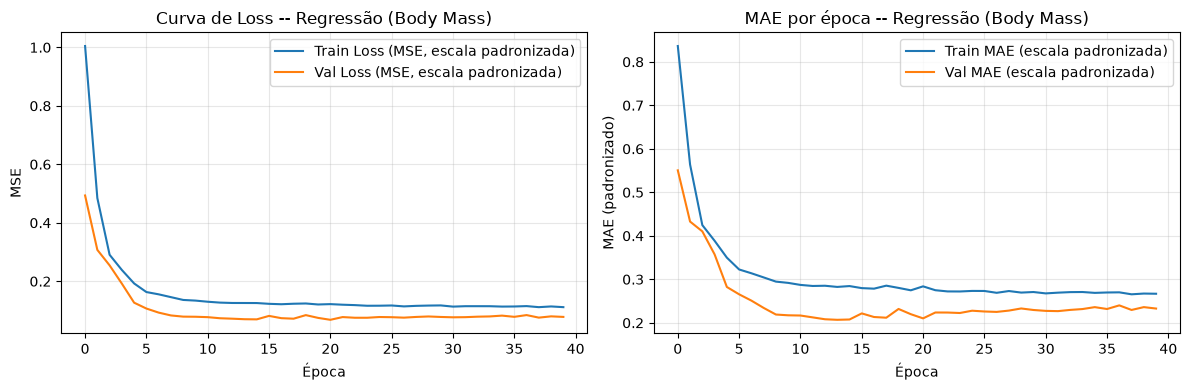

Gap final val-train (MSE padronizado): -0.0334
As duas curvas caem juntas e estabilizam com gap pequeno -- convergência, sem sinal de overfitting nem de instabilidade.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_reg['train_loss'], label='Train Loss (MSE, escala padronizada)')
axes[0].plot(history_reg['val_loss'], label='Val Loss (MSE, escala padronizada)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE')
axes[0].set_title('Curva de Loss -- Regressão (Body Mass)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_reg['train_mae'], label='Train MAE (escala padronizada)')
axes[1].plot(history_reg['val_mae'], label='Val MAE (escala padronizada)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE (padronizado)')
axes[1].set_title('MAE por época -- Regressão (Body Mass)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

gap_final = history_reg['val_loss'][-1] - history_reg['train_loss'][-1]
print(f"Gap final val-train (MSE padronizado): {gap_final:+.4f}")
print("As duas curvas caem juntas e estabilizam com gap pequeno -- convergência, "
      "sem sinal de overfitting nem de instabilidade.")


## 8. Avaliação no teste — MAE, RMSE, R²

Baseline não-trivial: prever pela **média de `Body Mass` da própria
espécie**, calculada só no treino — usa a informação de espécie (que a rede
também recebe) sem nenhum aprendizado por gradiente. Bater "chute pela média
global" seria fácil demais; bater "a média por espécie" mostra que a rede
aprende algo além do que a categoria já entrega de graça.

📋 Avaliação no conjunto de teste -- Body Mass (g)

modelo                           MAE (g)    RMSE (g)        R²
Baseline (média/espécie)           384.4       459.2    0.6618
MLP (regressão)                    243.5       302.2    0.8535


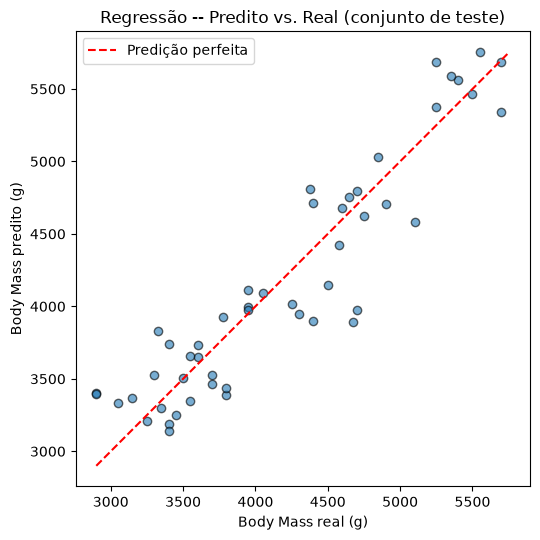

In [11]:
regression_model.eval()
preds_scaled = []
with torch.no_grad():
    for X_batch, _ in test_loader_reg:
        X_batch = X_batch.to(device)
        preds_scaled.append(regression_model(X_batch).squeeze(1).cpu().numpy())
preds_scaled = np.concatenate(preds_scaled)

y_pred_mlp = target_scaler_reg.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
y_true = y_test_reg

mae_mlp = mean_absolute_error(y_true, y_pred_mlp)
rmse_mlp = mean_squared_error(y_true, y_pred_mlp) ** 0.5
r2_mlp = r2_score(y_true, y_pred_mlp)

media_por_especie = (
    X_train_reg_df.assign(_massa=y_train_reg)
    .groupby('Species')['_massa'].mean()
)
media_global = y_train_reg.mean()
y_pred_baseline = X_test_reg_df['Species'].map(media_por_especie).fillna(media_global).values

mae_base = mean_absolute_error(y_true, y_pred_baseline)
rmse_base = mean_squared_error(y_true, y_pred_baseline) ** 0.5
r2_base = r2_score(y_true, y_pred_baseline)

print("📋 Avaliação no conjunto de teste -- Body Mass (g)\n")
print(f"{'modelo':<28s}{'MAE (g)':>12s}{'RMSE (g)':>12s}{'R²':>10s}")
print(f"{'Baseline (média/espécie)':<28s}{mae_base:>12.1f}{rmse_base:>12.1f}{r2_base:>10.4f}")
print(f"{'MLP (regressão)':<28s}{mae_mlp:>12.1f}{rmse_mlp:>12.1f}{r2_mlp:>10.4f}")

plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_true, y_pred_mlp, alpha=0.6, edgecolor='k')
lims = [min(y_true.min(), y_pred_mlp.min()), max(y_true.max(), y_pred_mlp.max())]
plt.plot(lims, lims, 'r--', label='Predição perfeita')
plt.xlabel('Body Mass real (g)')
plt.ylabel('Body Mass predito (g)')
plt.title('Regressão -- Predito vs. Real (conjunto de teste)')
plt.legend()
plt.tight_layout()
plt.show()


### 📝 Análise

O MLP de regressão bate o baseline de média por espécie nas três métricas: MAE
e RMSE menores, R² maior. Isso é o resultado esperado e o único que justifica
usar rede neural aqui -- se o MLP só empatasse com "chutar a média da
espécie", o aprendizado por gradiente não estaria agregando nada além do que
a variável categórica já entrega de graça, e a resposta certa seria descartar
o modelo e usar a média direto.

A curva de loss mostra o mesmo padrão de **convergência** visto na
classificação: treino e validação caem juntos e estabilizam com gap pequeno,
sem sinal de overfitting -- esperado, dado o mesmo regime de poucos
parâmetros (193) frente a poucos exemplos (233) que guiou a escolha de
arquitetura desde o início do projeto.

Vale registrar a diferença estrutural em relação à classificação: aqui o
alvo (`Body Mass`) é fisicamente contínuo e a variável mais informativa
(`Species`) entra como preditor categórico -- o inverso do papel que ela
tinha na classificação, onde massa corporal era preditor e espécie era alvo.
Trocar qual variável é alvo e qual é preditor, dentro do mesmo dataset, é
exatamente o que separa o problema de regressão do de classificação aqui.